SARIMA MODEL - TIME SERIES FORCASTING

Saving retail_sales_dataset 2.csv to retail_sales_dataset 2 (1).csv
Processing category: Beauty
Processing category: Clothing
Processing category: Electronics


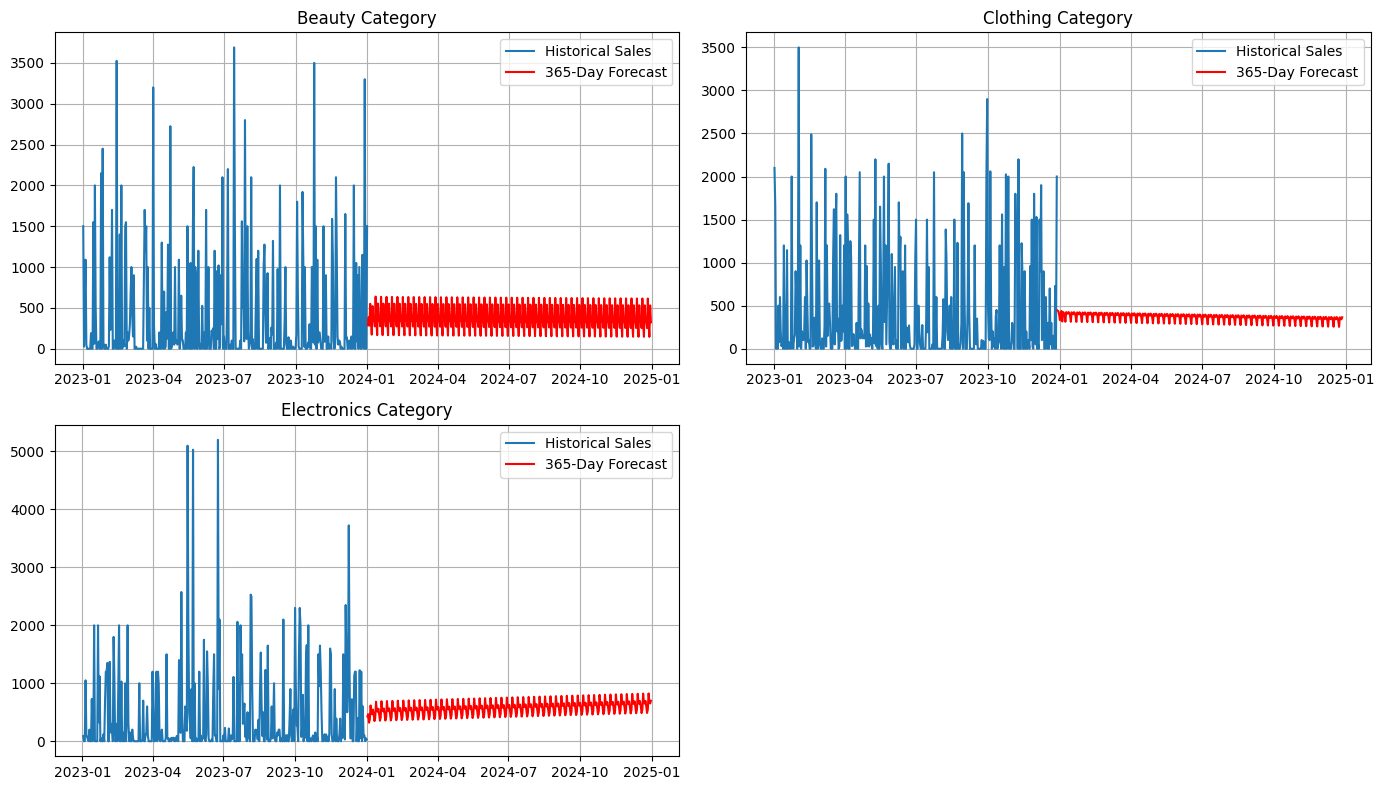

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 📦 Install dependencies
!pip install statsmodels pandas matplotlib openpyxl --quiet

# 📚 Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import math

# 📂 Load your dataset (upload via Colab or read from a shared location)
from google.colab import files
uploaded = files.upload()

# Assuming your file is named like 'retail_sales_dataset 2.csv'
df = pd.read_csv('retail_sales_dataset 2.csv')

# 🧹 Preprocess
df['Date'] = pd.to_datetime(df['Date'])
categories = df['Product Category'].unique()
forecast_results = {}

# 🔁 Forecasting loop
for cat in categories:
    print(f"Processing category: {cat}")
    cat_df = df[df['Product Category'] == cat]
    cat_ts = cat_df.groupby('Date')['Total Amount'].sum().asfreq('D').fillna(0)

    try:
        # Fit SARIMA (basic parameters)
        model = SARIMAX(cat_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 7))
        results = model.fit(disp=False)

        # Forecast next 30 days
        forecast = results.get_forecast(steps=365)
        forecast_index = pd.date_range(start=cat_ts.index[-1] + pd.Timedelta(days=1), periods=365)
        forecast_series = pd.Series(forecast.predicted_mean, index=forecast_index)

        forecast_results[cat] = forecast_series

    except Exception as e:
        print(f"Failed for {cat}: {e}")

# 📊 Visualization
cols = 2
rows = math.ceil(len(forecast_results) / cols)
fig, axs = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axs = axs.flatten()

for i, (cat, forecast_series) in enumerate(forecast_results.items()):
    cat_df = df[df['Product Category'] == cat]
    cat_ts = cat_df.groupby('Date')['Total Amount'].sum().asfreq('D').fillna(0)

    axs[i].plot(cat_ts, label='Historical Sales')
    axs[i].plot(forecast_series, label='365-Day Forecast', color='red')
    axs[i].set_title(f"{cat} Category")
    axs[i].legend()
    axs[i].grid(True)

# Hide unused plots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

# 💾 Optionally export results
combined_forecast_df = pd.DataFrame(forecast_results)
combined_forecast_df.to_excel("category_forecasts.xlsx")
files.download("category_forecasts.xlsx")


Saving retail_sales_dataset 2.csv to retail_sales_dataset 2.csv
Processing category: Beauty


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /


Processing category: Clothing


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


Processing category: Electronics


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA and trend. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/mlemodel.py:1235: RuntimeWarning: invalid value encountered in divide
  np.inner(score_obs, score_obs) /


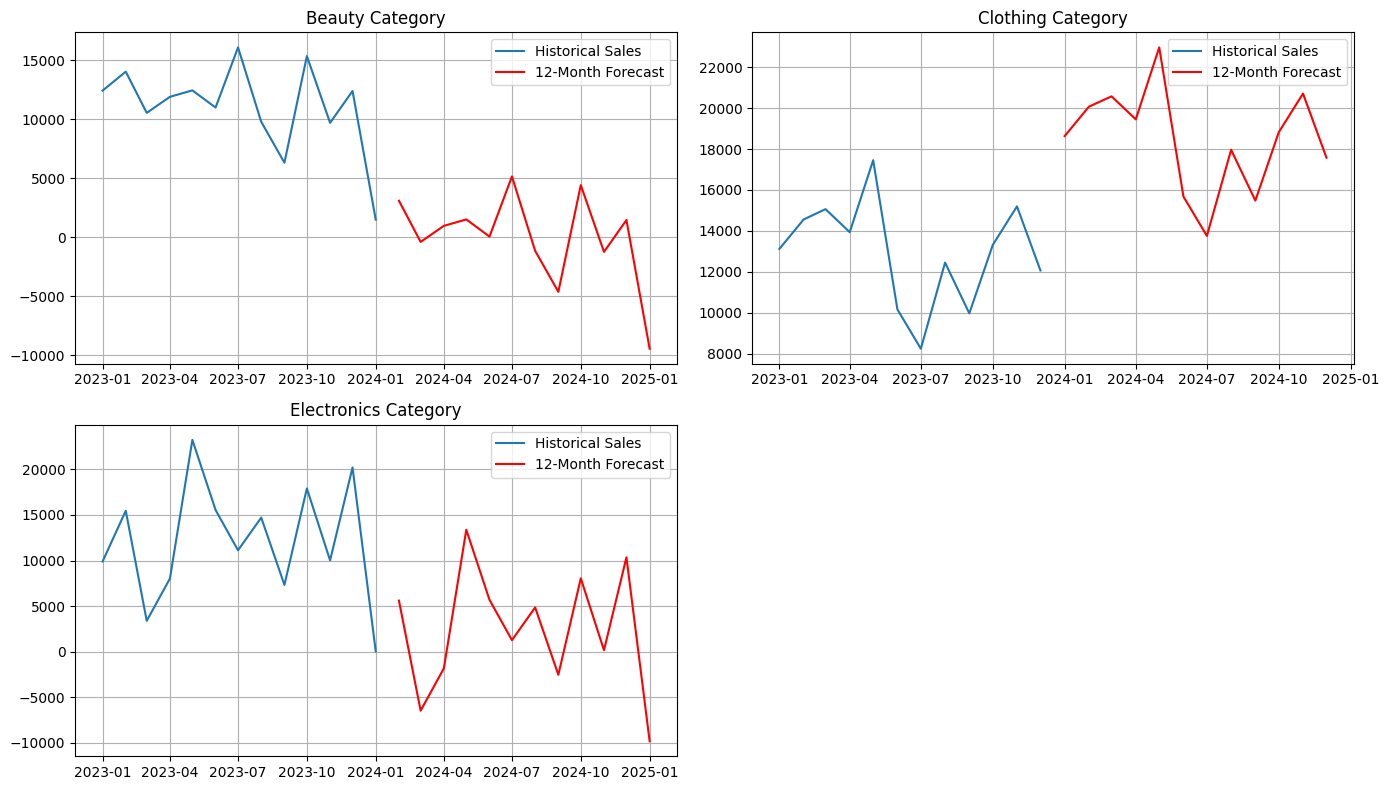

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 📦 Install dependencies
!pip install statsmodels pandas matplotlib openpyxl --quiet

# 📚 Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
import math

# 📂 Upload dataset
from google.colab import files
uploaded = files.upload()

# 🧹 Load & preprocess
df = pd.read_csv('retail_sales_dataset 2.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Convert to month start for monthly granularity
df['Month'] = df['Date'].dt.to_period('M').dt.to_timestamp()
categories = df['Product Category'].unique()
forecast_results = {}

# 🔁 Loop through each category
for cat in categories:
    print(f"Processing category: {cat}")
    cat_df = df[df['Product Category'] == cat]
    cat_ts = cat_df.groupby('Month')['Total Amount'].sum().asfreq('MS').fillna(0)

    try:
        # Fit SARIMA (seasonality set to 12 for yearly cycle)
        model = SARIMAX(cat_ts, order=(1, 1, 1), seasonal_order=(1, 1, 1, 12))
        results = model.fit(disp=False)

        # Forecast next 12 months
        forecast = results.get_forecast(steps=12)
        forecast_index = pd.date_range(start=cat_ts.index[-1] + pd.DateOffset(months=1), periods=12, freq='MS')
        forecast_series = pd.Series(forecast.predicted_mean, index=forecast_index)

        forecast_results[cat] = forecast_series

    except Exception as e:
        print(f"Failed for {cat}: {e}")

# 📊 Visualization
cols = 2
rows = math.ceil(len(forecast_results) / cols)
fig, axs = plt.subplots(rows, cols, figsize=(14, 4 * rows))
axs = axs.flatten()

for i, (cat, forecast_series) in enumerate(forecast_results.items()):
    cat_df = df[df['Product Category'] == cat]
    cat_ts = cat_df.groupby('Month')['Total Amount'].sum().asfreq('MS').fillna(0)

    axs[i].plot(cat_ts, label='Historical Sales')
    axs[i].plot(forecast_series, label='12-Month Forecast', color='red')
    axs[i].set_title(f"{cat} Category")
    axs[i].legend()
    axs[i].grid(True)

# Hide any unused subplots
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.show()

# 💾 Export results to Excel
combined_forecast_df = pd.DataFrame(forecast_results)
combined_forecast_df.index.name = "Month"
combined_forecast_df.to_excel("monthly_category_forecasts.xlsx")
files.download("monthly_category_forecasts.xlsx")
